# Install libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import os

plt.style.use('ggplot')

DATASET_PATH = os.path.join(os.getcwd(), '..', 'data', 'Injury_History.csv')

# Creating DataFrame

In [3]:
df = pd.read_csv(DATASET_PATH)
df.head(10)

,Name,Team,Position,Date,Notes
0,Jaylen Brown,Boston Celtics,SG,11/01/2017,sprained right ankle (DTD)
1,Jaylen Brown,Boston Celtics,SG,13/01/2017,returned to lineup
2,Jaylen Brown,Boston Celtics,SG,13/02/2017,placed on IL with strained right hip flexor
3,Jaylen Brown,Boston Celtics,SG,24/02/2017,activated from IL
4,Jaylen Brown,Boston Celtics,SG,06/12/2017,placed on IL with right eye inflammation
5,Jaylen Brown,Boston Celtics,SG,08/12/2017,activated from IL
6,Jaylen Brown,Boston Celtics,SG,21/12/2017,sore left Achilles (DTD)
7,Jaylen Brown,Boston Celtics,SG,23/12/2017,returned to lineup
8,Jaylen Brown,Boston Celtics,SG,27/12/2017,placed on IL
9,Jaylen Brown,Boston Celtics,SG,27/12/2017,sore right knee (DTD)


# Data Understanding

In [9]:
df.shape

(9280, 5)

In [19]:
df.isnull().sum()

Name        0
Team        0
Position    0
Date        0
Notes       0
dtype: int64

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9280 entries, 0 to 9279
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      9280 non-null   object
 1   Team      9280 non-null   object
 2   Position  9280 non-null   object
 3   Date      9280 non-null   object
 4   Notes     9280 non-null   object
dtypes: object(5)
memory usage: 362.6+ KB


In [4]:
df.duplicated().sum()

np.int64(1)

In [5]:
df[df.duplicated(keep=False)]

,Name,Team,Position,Date,Notes
8156,Aaron Gordon,Denver Nuggets,PF,24/10/2017,activated from IL
8157,Aaron Gordon,Denver Nuggets,PF,24/10/2017,activated from IL


It seems that we have one duplicate, probably an error made by dataset creators

In [6]:
df.describe()


,Name,Team,Position,Date,Notes
count,9280,9280,9280,9280,9280
unique,344,30,7,1734,1552
top,Kevin Love,Los Angeles Lakers,C,12/04/2017,activated from IL
freq,139,715,1943,35,2480


In [7]:
df['Position'].value_counts()

Position
C     1943
PF    1835
PG    1823
SG    1634
SF    1562
F      278
G      205
Name: count, dtype: int64

Text(0, 0.5, 'Sum of injuries')

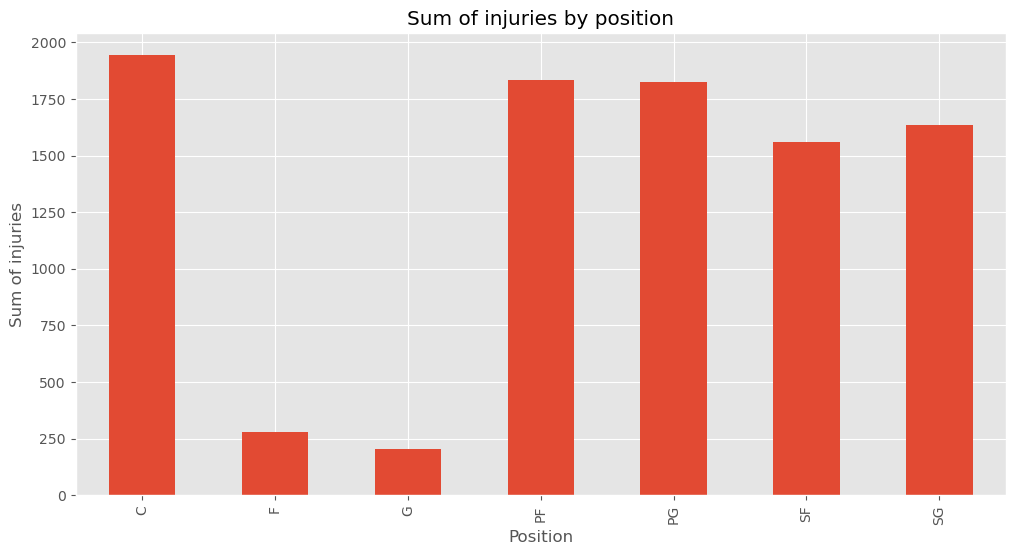

In [12]:
plt.figure(figsize=(12, 6))
position_by_injuries = df.groupby('Position')['Notes'].count()
plt.subplot()
position_by_injuries.plot(kind='bar')
plt.title('Sum of injuries by position')
plt.ylabel('Sum of injuries')

In [15]:
for val in df['Notes'].unique():
    print(val)

sprained right ankle (DTD)
returned to lineup
placed on IL with strained right hip flexor
activated from IL
placed on IL with right eye inflammation
sore left Achilles (DTD)
placed on IL
sore right knee (DTD)
concussion (out indefinitely)
placed on IL with concussion
strained right hamstring (DTD)
placed on IL with sore right foot
placed on IL with bruised lower back
illness (DTD)
placed on IL with lower back spasms
placed on IL with illness
placed on IL with sprained right thumb
placed on IL with sprained right ankle
placed on IL with left calf injury
placed on IL with strained right hamstring
right hand injury (DTD)
dislocated left index finger (out indefinitely)
placed on IL with dislocated left index finger
patellar tendinitis in left knee (DTD)
sprained right toe (out for season)
placed on IL with sprained right toe (out for season)
sprained MCL in left knee (out indefinitely)
placed on IL with sprained MCL in left knee
placed on IL with bruised tailbone
placed on IL with migraine

# EDA (part 1)

Since we have extra values F and G positions which are probably bench players with no designated spot in roster we can join PF AND SF to F group, as well as PG AND SG to G group, because essentially those are the same positions

Text(0, 0.5, 'Percentage of each Position')

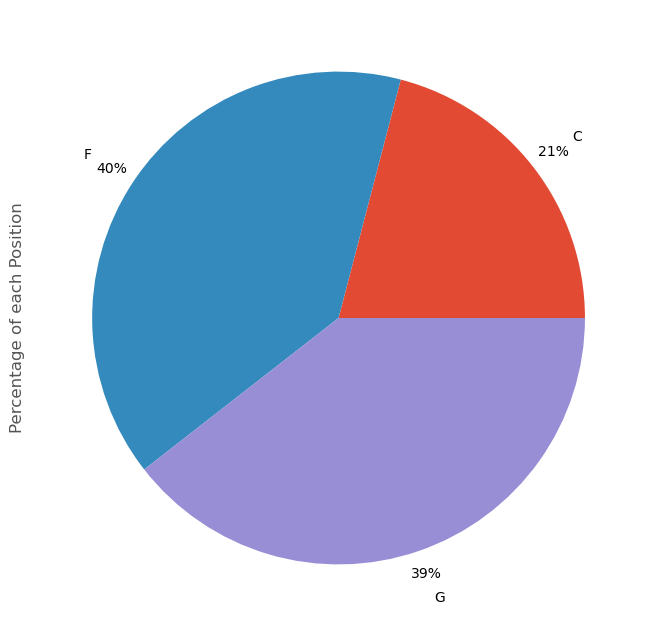

In [14]:
df["Position"] = df["Position"].replace({'PG':'G','SG':'G','SF':'F','PF':'F'})

plt.figure(figsize=(12,8))

df.groupby('Position')['Notes'].count().plot(kind="pie",autopct='%1.0f%%', pctdistance=1.1, labeldistance=1.2)
plt.ylabel('Percentage of each Position')

<Axes: xlabel='Date'>

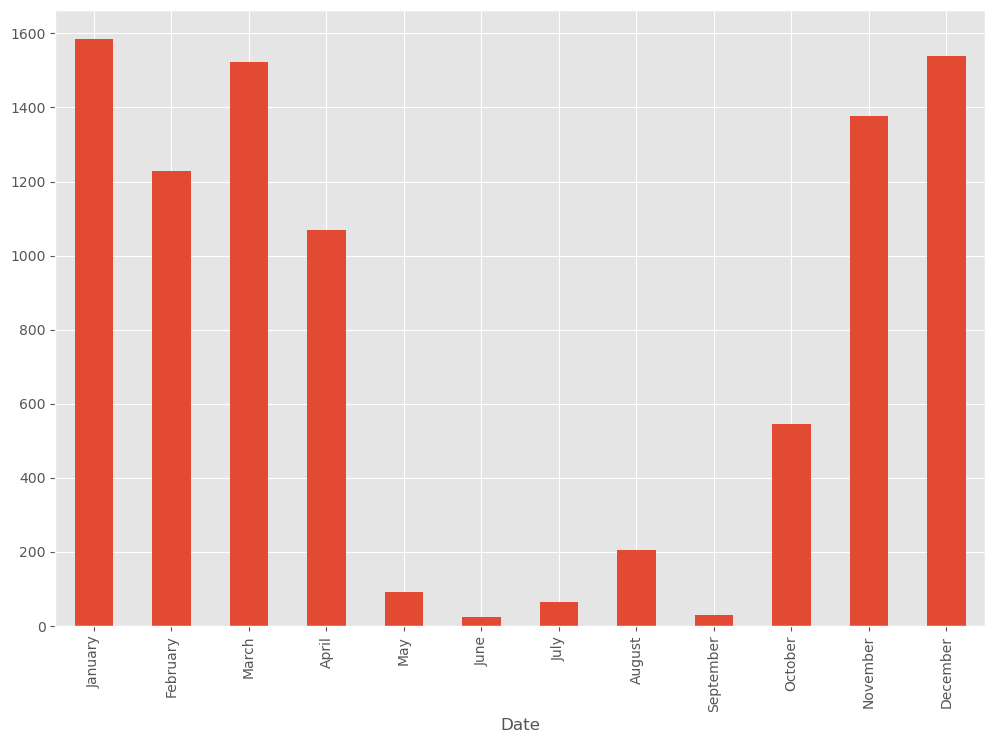

In [17]:
df['Date'] = pd.to_datetime(df['Date'], format="%d/%m/%Y")
plt.figure(figsize=(12,8))

months = ['January', 'February', 'March', 'April',
          'May', 'June', 'July', 'August',
          'September', 'October', 'November', 'December']

df.groupby(df["Date"].dt.strftime("%B"))["Notes"].count().reindex(months).plot(kind="bar")

We can see that most of injuries happens outside of playoff phase which is between April and June. Most eventful are December and January, it might be because of all-star break that happens in February so players want to make the best impression and they give their all. Also March is very full of injuries which might be, because regular season ends mid-april, so the teams try to do their best to secure best seed. Rest of months are not as injury-high, since it's either break from regular season or the season is etither just starting or ending.

<Axes: xlabel='Date'>

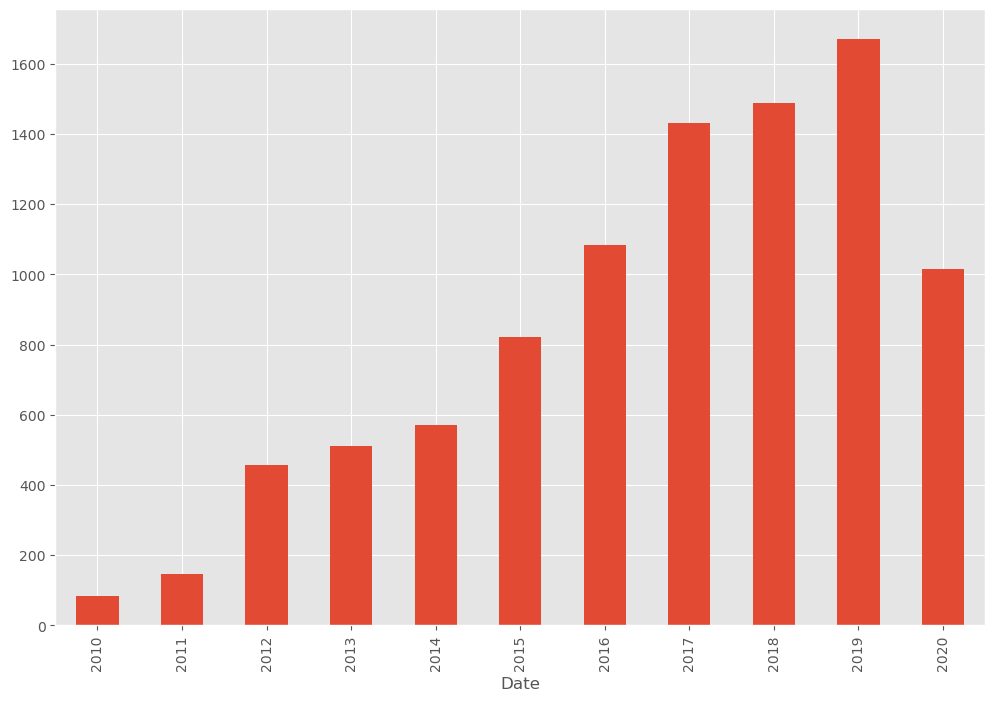

In [18]:
plt.figure(figsize=(12,8))

df.groupby(df["Date"].dt.strftime("%Y"))["Notes"].count().plot(kind="bar")

The problem here in this dataset might be the fact that authors might not have included all data for such years like 2010, 2011 and 2020, since either not enough data was available online. On the other hand in 2020 NBA season was suspended on March 11, beacuse of pandemic and it only resumed on July 30. 

Anyway we can see clear increase in injuries, which might be because teams are more conscious about workload managment and the players rest more. Unfortunately teams anyway list players who are supposed to rest as either "DNP" which is treated more or less like injury or they report fake/small injury of a player.

# Insights 
(For this part of Dataset)
* Clearly for further EDA I need to import another dataset with information about minutes played, weight, salary etc. of players
* I need to filter out non-injury notes and recognize most important injuries.
* Most of injuries are happening to Forwards
* Data is preatty neat and doesn't need a lot of cleaning

# EDA (part 2)

This dataset contains statistics in each game played by player active in season 2021-2022

In [5]:
DATASET_PATH = os.path.join(os.getcwd(), '..', 'data', 'gamelogs_2021_22.csv')
pd.set_option('display.max_columns',50)

df = pd.read_csv(DATASET_PATH)
df.head(10)

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,PLAYER_ID,PLAYER_NAME
0,22021,1630173,22101226,"Apr 10, 2022",TOR @ NYK,L,26,4,13,0.308,1,5,0.200,0,0,0.00,2,4,6,2,1,1,1,2,9,-7,1,1630173,Precious Achiuwa
1,22021,1630173,22101206,"Apr 08, 2022",TOR vs. HOU,W,12,2,5,0.400,1,3,0.333,3,3,1.00,0,1,1,0,0,1,2,2,8,-28,1,1630173,Precious Achiuwa
2,22021,1630173,22101197,"Apr 07, 2022",TOR vs. PHI,W,40,7,11,0.636,5,7,0.714,1,2,0.50,1,3,4,2,1,1,5,1,20,5,1,1630173,Precious Achiuwa
3,22021,1630173,22101182,"Apr 05, 2022",TOR vs. ATL,W,24,4,11,0.364,0,4,0.000,3,5,0.60,1,1,2,0,1,0,0,1,11,21,1,1630173,Precious Achiuwa
4,22021,1630173,22101172,"Apr 03, 2022",TOR vs. MIA,L,21,1,4,0.250,0,1,0.000,1,4,0.25,0,2,2,1,0,0,1,2,3,-2,1,1630173,Precious Achiuwa
5,22021,1630173,22101151,"Apr 01, 2022",TOR @ ORL,W,16,4,6,0.667,1,3,0.333,2,2,1.00,1,2,3,1,0,0,0,1,11,-10,1,1630173,Precious Achiuwa
6,22021,1630173,22101141,"Mar 30, 2022",TOR vs. MIN,W,22,5,9,0.556,3,7,0.429,0,0,0.00,1,3,4,1,1,0,1,2,13,20,1,1630173,Precious Achiuwa
7,22021,1630173,22101127,"Mar 28, 2022",TOR vs. BOS,W,28,3,10,0.300,1,4,0.250,0,2,0.00,2,6,8,0,0,4,1,3,7,6,1,1630173,Precious Achiuwa
8,22021,1630173,22101109,"Mar 26, 2022",TOR vs. IND,W,24,7,12,0.583,4,5,0.800,0,0,0.00,2,4,6,4,1,0,0,1,18,30,1,1630173,Precious Achiuwa
9,22021,1630173,22101095,"Mar 24, 2022",TOR vs. CLE,W,22,3,10,0.300,0,3,0.000,4,4,1.00,0,4,4,1,0,0,0,2,10,8,1,1630173,Precious Achiuwa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26039 entries, 0 to 26038
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SEASON_ID        26039 non-null  int64  
 1   Player_ID        26039 non-null  int64  
 2   Game_ID          26039 non-null  int64  
 3   GAME_DATE        26039 non-null  object 
 4   MATCHUP          26039 non-null  object 
 5   WL               26039 non-null  object 
 6   MIN              26039 non-null  int64  
 7   FGM              26039 non-null  int64  
 8   FGA              26039 non-null  int64  
 9   FG_PCT           26039 non-null  float64
 10  FG3M             26039 non-null  int64  
 11  FG3A             26039 non-null  int64  
 12  FG3_PCT          26039 non-null  float64
 13  FTM              26039 non-null  int64  
 14  FTA              26039 non-null  int64  
 15  FT_PCT           26039 non-null  float64
 16  OREB             26039 non-null  int64  
 17  DREB        

In [6]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,SEASON_ID,Player_ID,Game_ID,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,PLAYER_ID
count,26039.0,2.603900e+04,2.603900e+04,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,26039.000000,2.603900e+04
mean,22021.0,1.184053e+06,2.210061e+07,22.807059,3.837705,8.322977,0.428455,1.175084,3.323284,0.255782,1.599793,2.065402,0.424121,0.976305,3.223050,4.199355,2.328661,0.720919,0.445255,1.233419,1.855140,10.450286,0.001536,1.000691,1.184053e+06
std,0.0,6.638227e+05,3.557229e+02,10.717516,3.169424,5.927189,0.251477,1.483825,3.058099,0.289477,2.248933,2.717189,0.434006,1.346070,2.751718,3.457344,2.581280,0.951769,0.787843,1.395863,1.472716,8.550396,11.541231,0.026283,6.638227e+05
min,22021.0,2.207000e+03,2.210000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-56.000000,1.000000,2.207000e+03
25%,22021.0,2.035850e+05,2.210030e+07,15.000000,1.000000,4.000000,0.286000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,-7.000000,1.000000,2.035850e+05
50%,22021.0,1.628425e+06,2.210061e+07,24.000000,3.000000,7.000000,0.444000,1.000000,3.000000,0.200000,1.000000,1.000000,0.500000,1.000000,3.000000,3.000000,2.000000,0.000000,0.000000,1.000000,2.000000,9.000000,0.000000,1.000000,1.628425e+06
75%,22021.0,1.629684e+06,2.210092e+07,32.000000,6.000000,12.000000,0.571000,2.000000,5.000000,0.500000,2.000000,3.000000,1.000000,1.000000,5.000000,6.000000,3.000000,1.000000,1.000000,2.000000,3.000000,15.000000,7.000000,1.000000,1.629684e+06
max,22021.0,1.630994e+06,2.210123e+07,57.000000,22.000000,37.000000,1.000000,11.000000,20.000000,1.000000,23.000000,27.000000,1.000000,12.000000,21.000000,25.000000,19.000000,8.000000,8.000000,10.000000,6.000000,60.000000,52.000000,2.000000,1.630994e+06


In [ ]:
df['Player_ID'].nunique()

np.int64(25434)

In [8]:
df.describe(include='object')

,GAME_DATE,MATCHUP,WL,PLAYER_NAME
count,26039,26039,26039,26039
unique,165,1740,2,605
top,"Apr 10, 2022",UTA vs. POR,W,Kevon Looney
freq,309,28,13120,82


Luckily that season, there wasn't two players with the same Full name

Since, we can see that Kevon Looney played every game this season, we can use him as an example to show distribution of few values, after checking distributio of numerical values of whole dataset

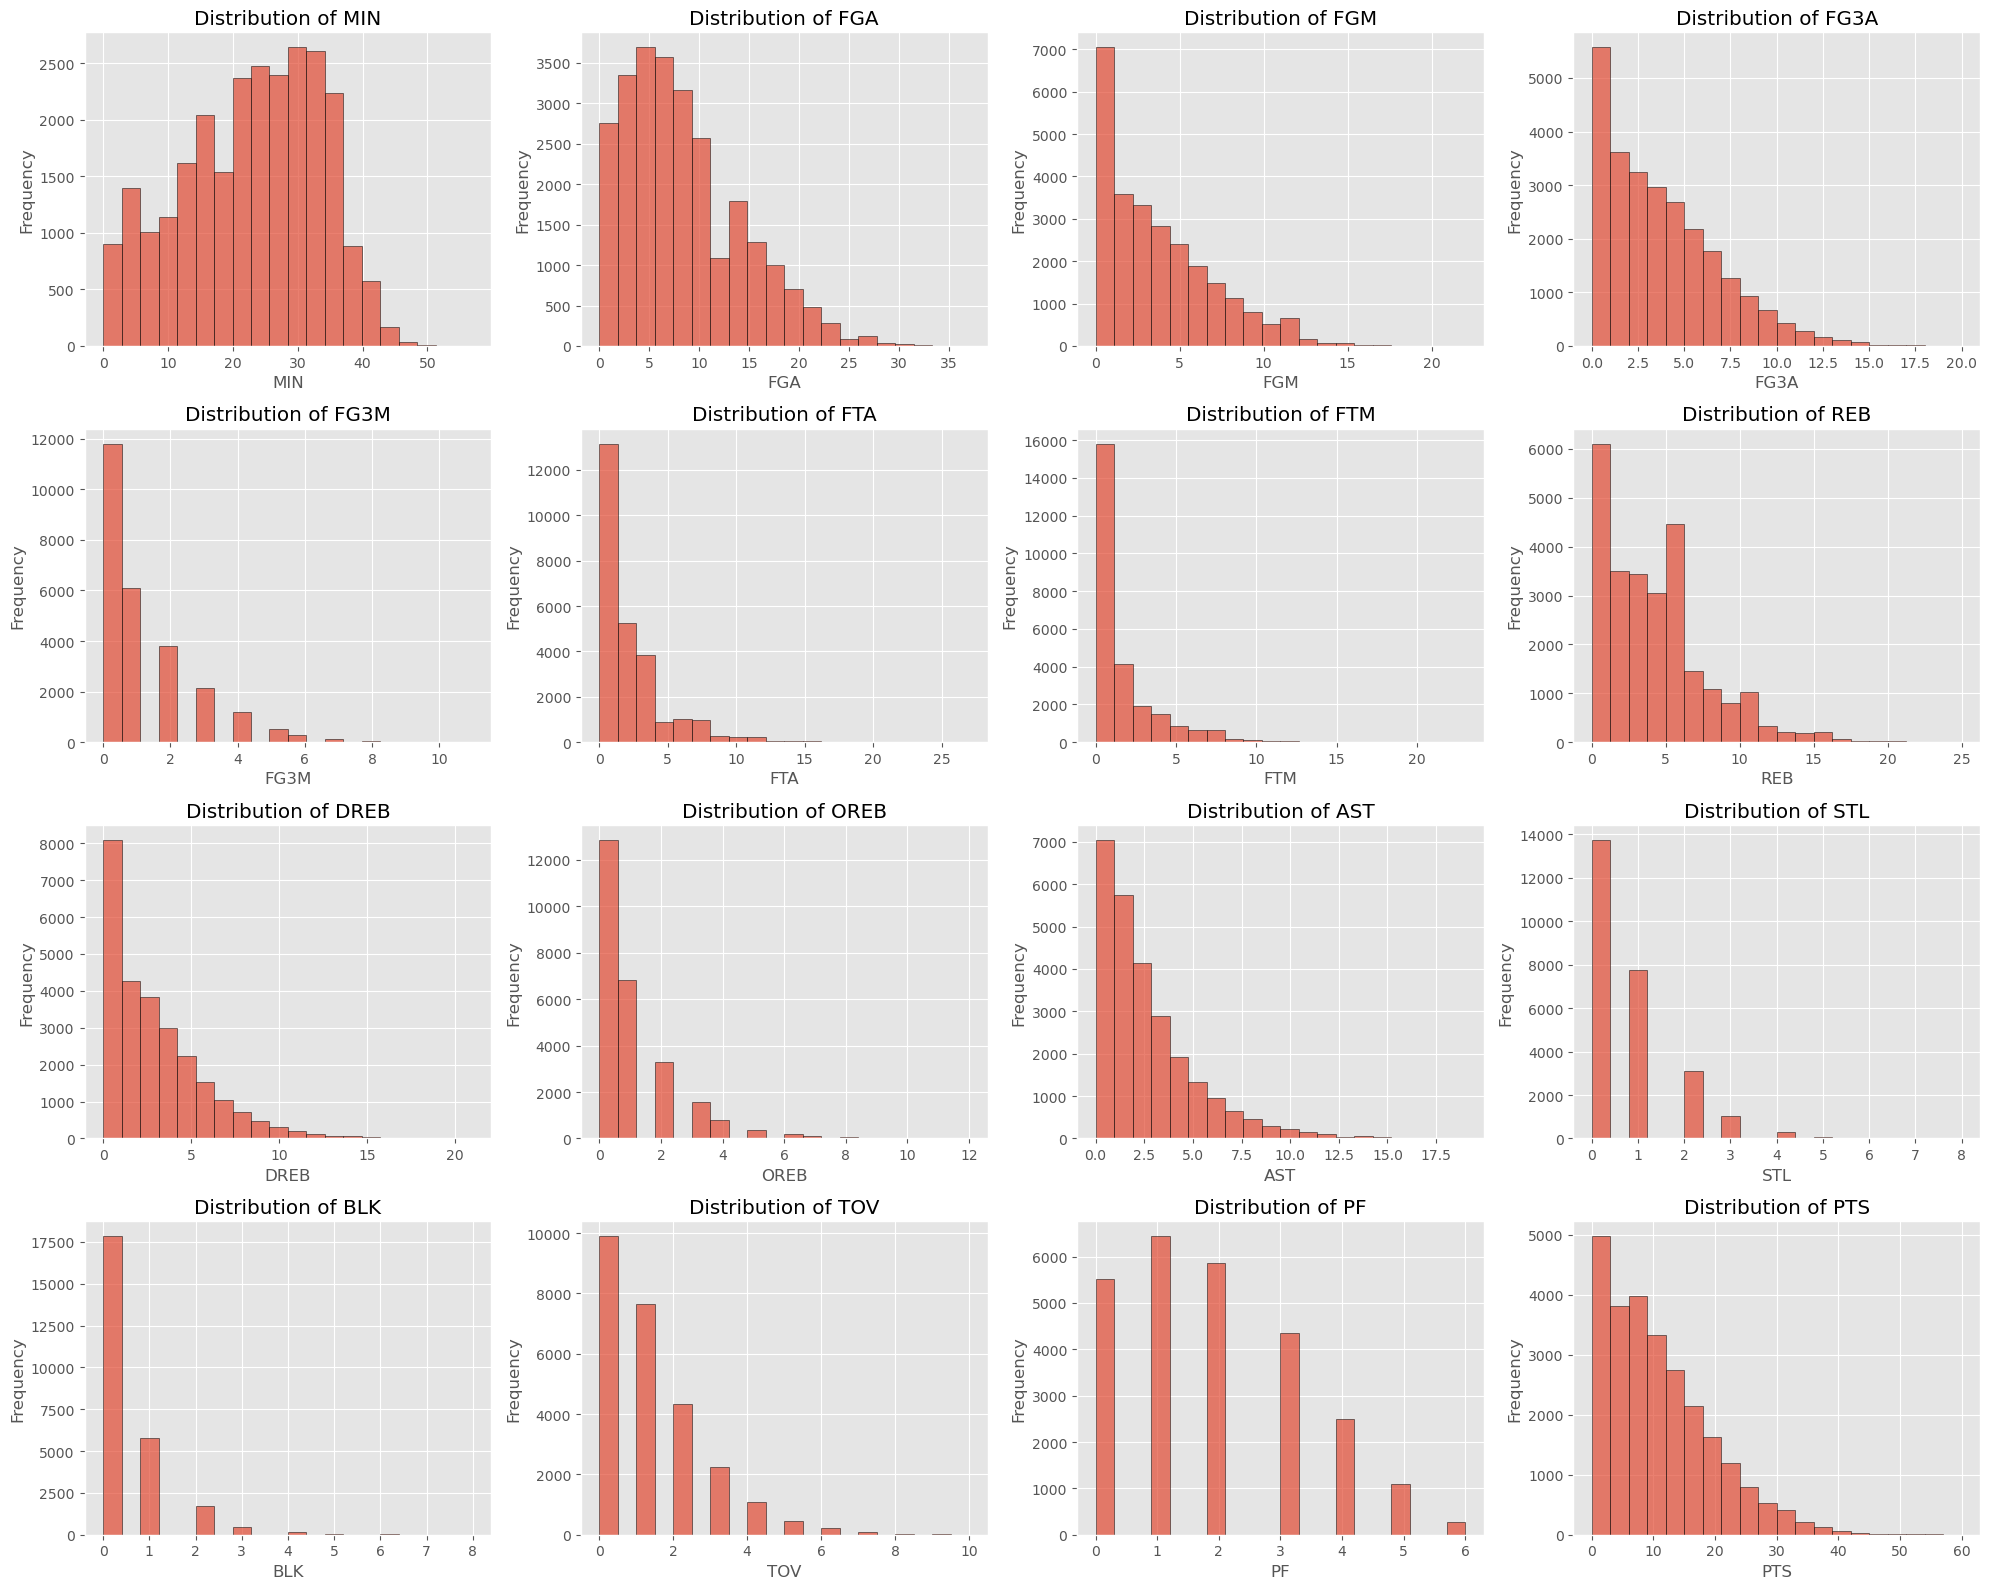

In [24]:
# UNIVARIATE  ANALYSIS OF NUMERICAL VALUES FOR KEVON LOONEY
fig, axes = plt.subplots(4, 4, figsize=(20,16))
numerical_cols = ['MIN', 'FGA', 'FGM', 'FG3A', 'FG3M', 'FTA', 'FTM', 'REB', 'DREB', 'OREB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']


for i, col in enumerate(numerical_cols):
    row, col_idx = i // 4, i % 4
    axes[row, col_idx].hist(df[col], bins=20, alpha=0.7, edgecolor='black')
    axes[row, col_idx].set_title(f'Distribution of {col}')
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].set_xlabel(col)

plt.tight_layout()
plt.show()

Despite the fact that mostly players spend around 30 mins on the floor, a lot of the players do "nothing" during match. We have a lot of 0 field goals made or no free throws made. Since we have 605 active players this season, it shouldn't surprise us, because a lot of those players are role-players and they have very specific tasks (such as only rebounding etc.).

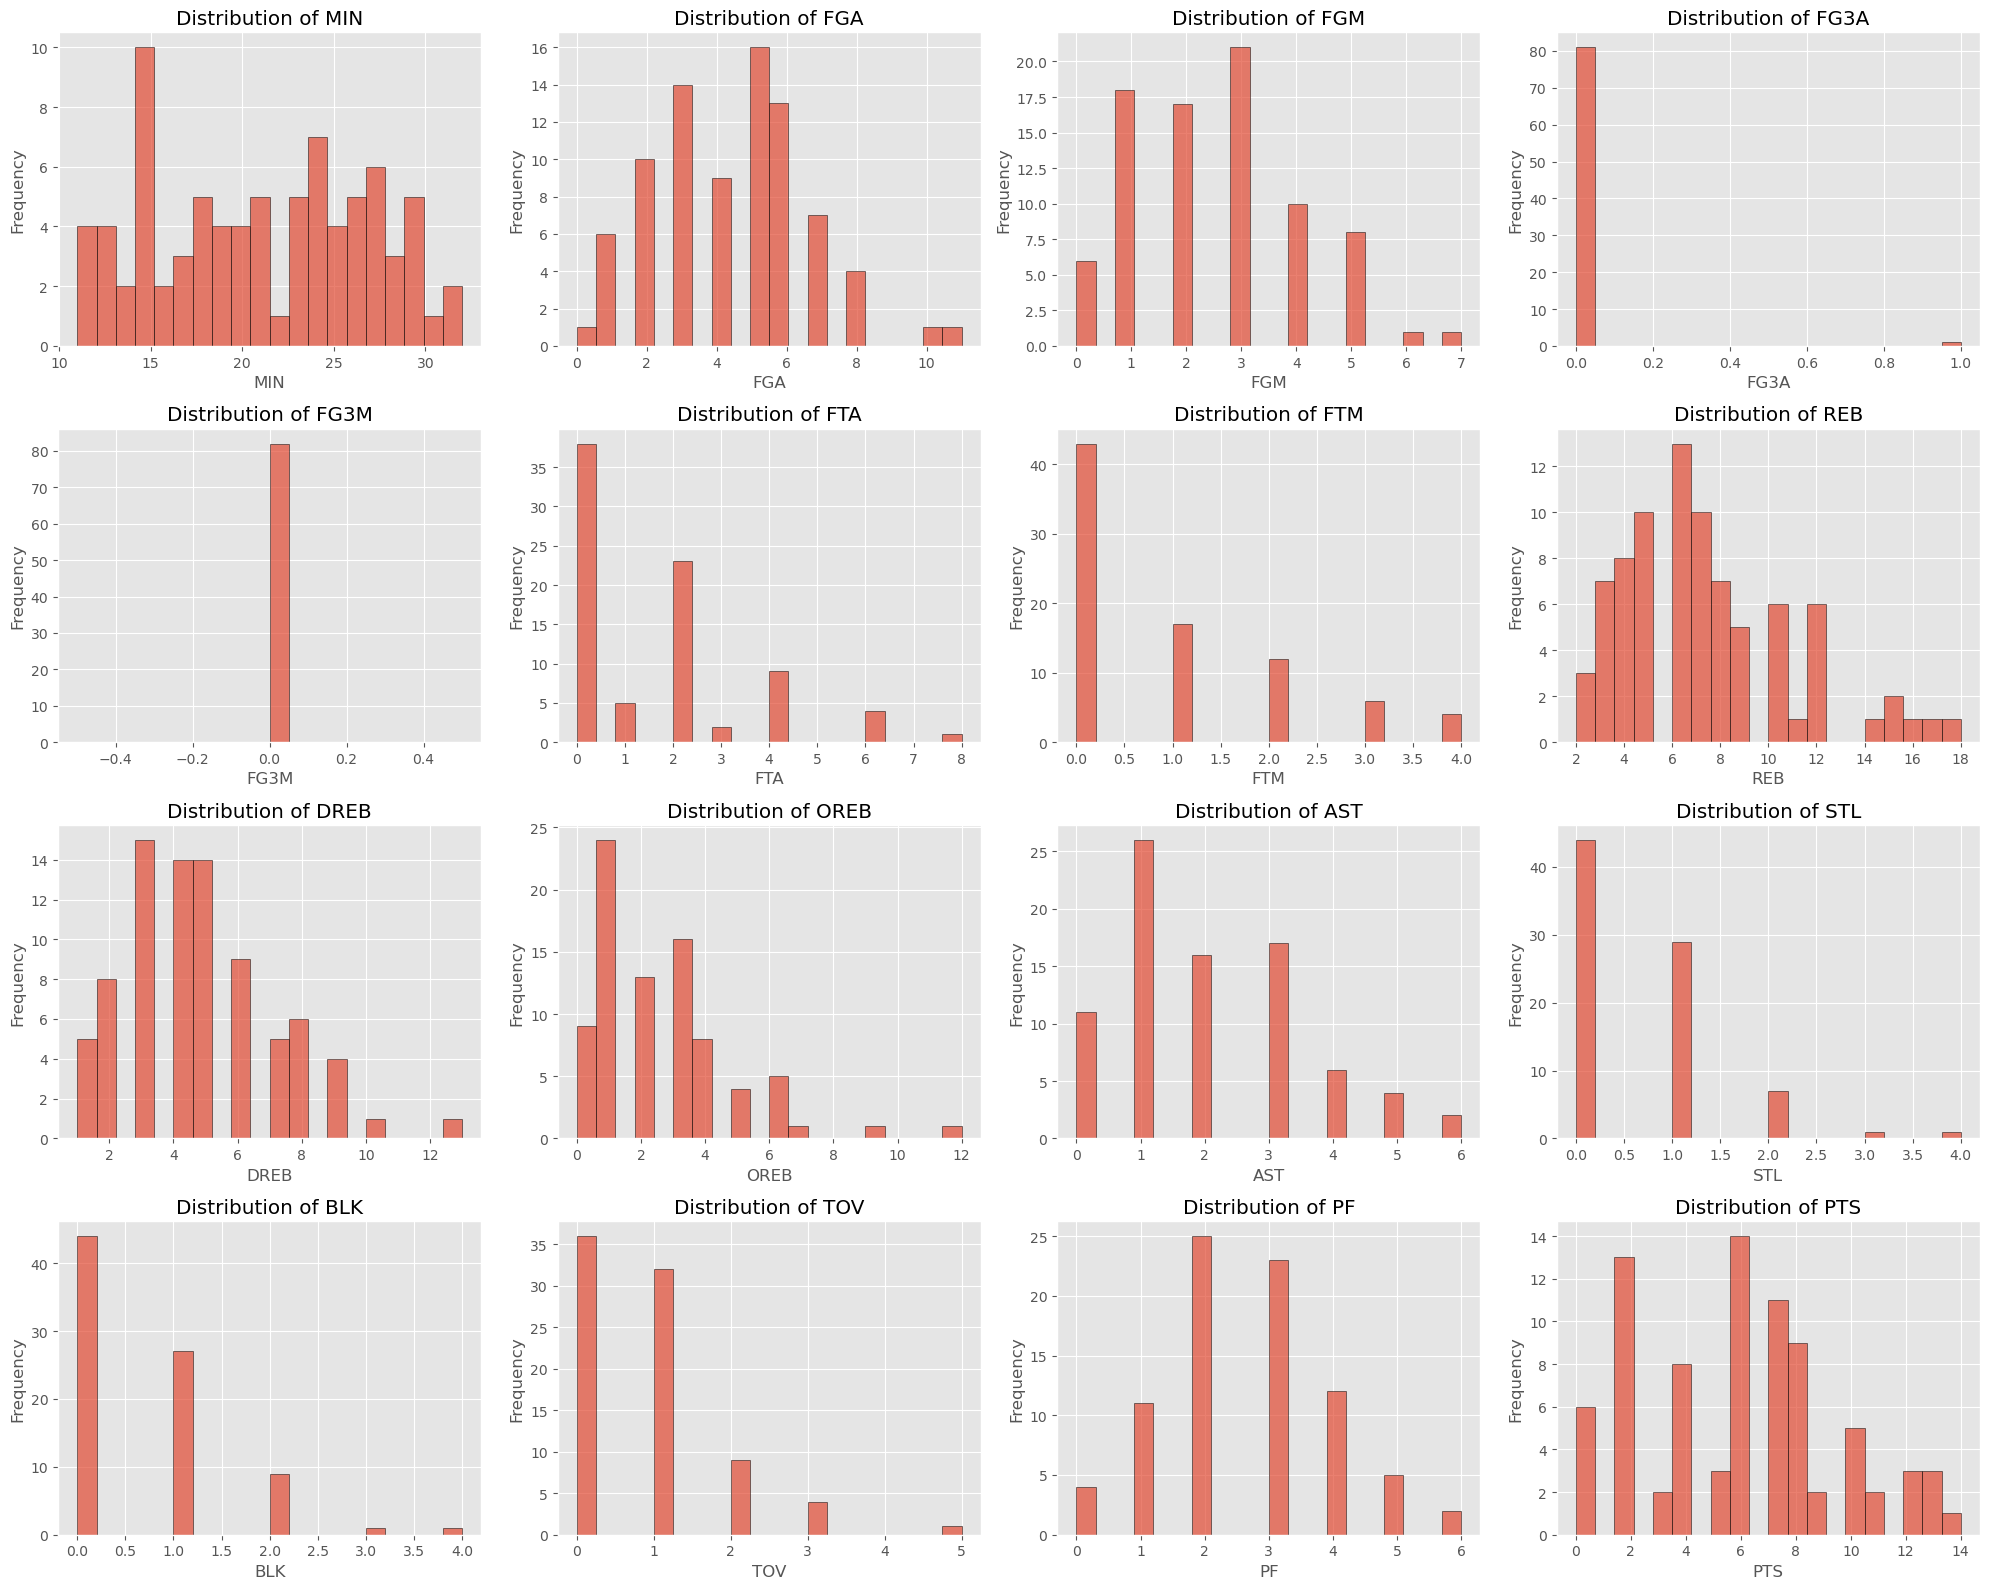

In [23]:
# UNIVARIATE  ANALYSIS OF NUMERICAL VALUES FOR KEVON LOONEY
fig, axes = plt.subplots(4, 4, figsize=(20,16))

df_KL = df[df['PLAYER_NAME'] == 'Kevon Looney']

for i, col in enumerate(numerical_cols):
    row, col_idx = i // 4, i % 4
    axes[row, col_idx].hist(df_KL[col], bins=20, alpha=0.7, edgecolor='black')
    axes[row, col_idx].set_title(f'Distribution of {col}')
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].set_xlabel(col)

plt.tight_layout()
plt.show()

Kevon Looney in 2021-2022 season was a center for Golden State Warriors, so that is not surprising that he hasn't attempted any 3 point shot, but he has a lot of rebounds and he usually played around 15 mins a match.